In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Activation vs repression

## Imports

In [19]:
import os
import pandas as pd
import re

from synbio_morpher.utils.misc.type_handling import flatten_listlike
from synbio_morpher.utils.data.data_format_tools.common import load_json_as_dict
from synbio_morpher.srv.io.manage.script_manager import script_preamble
from synbio_morpher.utils.misc.string_handling import string_to_tuple_list
from synbio_morpher.utils.misc.type_handling import get_nth_elements

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import jax
import subprocess

from run_bpRNA import aggregate_motifs, run_bpRNA




## Load data

In [20]:
fn_inter = os.path.join('..', 'data', 'sRNA', 'merged_inter.csv')
fn_merged = os.path.join('..', 'data', 'sRNA', 'merged_EcoCyc_RNAInter_sRNATarBase.csv')
data = pd.read_csv(fn_inter)
merged = pd.read_csv(fn_merged)
try:
    data = data.drop(columns=['Unnamed: 0'])
    merged = merged.drop(columns=['Unnamed: 0'])
except:
    pass


# Binding energy differences 

In [21]:
# interaction_data = load_json_as_dict('./data/05_orthogonality_mRNA_official/2023_11_21_095238/inter_data_raw.json')
interaction_data = load_json_as_dict('./data/tests/2023_11_21_095238/inter_data_raw.json')
# interaction_data = load_json_as_dict('./data/tests/2023_11_28_205928/inter_data_raw.json')
# interaction_data = load_json_as_dict('./data/tests/2026_03_26_230917/inter_data_raw.json')
# interaction_data = load_json_as_dict('./data/tests/2024_02_20_103403/inter_data_raw.json')
len(interaction_data)

37

In [24]:
data['Interaction Energy'] = 0.0
data['bpList'] = ''
data['hybridDPfull'] = ''
data['seedPu1'] = ''
data['seedPu2'] = ''
for k1 in interaction_data:
    for k2, v in interaction_data[k1].items():
        i1, i2 = k1, k2
        if k1 in data['Interactor 1'].to_list():
            i1, i2 = k1, k2
            # data.loc[(data['Interactor 1'] == k1) & (data['Interactor 2'] == k2), 'Interaction Energy'] = float(v['E'])
            # data.loc[(data['Interactor 1'] == k1) & (data['Interactor 2'] == k2), 'bpList'] = v['bpList']
            # data.loc[(data['Interactor 1'] == k1) & (data['Interactor 2'] == k2), 'hybridDPfull'] = v['hybridDPfull']
            # data.loc[(data['Interactor 1'] == k1) & (data['Interactor 2'] == k2), 'seedPu1'] = v['seedPu1']
            # data.loc[(data['Interactor 1'] == k1) & (data['Interactor 2'] == k2), 'seedPu2'] = v['seedPu2']
        elif k2 in data['Interactor 1'].to_list():
            i1, i2 = k2, k1
            # data.loc[(data['Interactor 1'] == k2) & (data['Interactor 2'] == k1), 'Interaction Energy'] = float(v['E'])
            # data.loc[(data['Interactor 1'] == k2) & (data['Interactor 2'] == k1), 'bpList'] = v['bpList']
            # data.loc[(data['Interactor 1'] == k2) & (data['Interactor 2'] == k1), 'hybridDPfull'] = v['hybridDPfull']
            # data.loc[(data['Interactor 1'] == k2) & (data['Interactor 2'] == k1), 'seedPu1'] = v['seedPu1']
            # data.loc[(data['Interactor 1'] == k2) & (data['Interactor 2'] == k1), 'seedPu2'] = v['seedPu2']
        else:
            # print(k1, k2)
            pass
        if k1 in v:
            v = v[k1]
        data.loc[(data['Interactor 1'] == i1) & (data['Interactor 2'] == i2), 'Interaction Energy'] = float(v['E'])
        data.loc[(data['Interactor 1'] == i1) & (data['Interactor 2'] == i2), 'bpList'] = v['bpList']
        data.loc[(data['Interactor 1'] == i1) & (data['Interactor 2'] == i2), 'hybridDPfull'] = v['hybridDPfull']
        data.loc[(data['Interactor 1'] == i1) & (data['Interactor 2'] == i2), 'seedPu1'] = v.get('seedPu1', '')
        data.loc[(data['Interactor 1'] == i1) & (data['Interactor 2'] == i2), 'seedPu2'] = v.get('seedPu2', '')

data

        

,Interactor 1,Interactor 2,ID 1,ID 2,Category 1,Category 2,Regulation,Binding position 1,Binding position 2,Sequence 1,...,Strand 2,Sequence before 1,Sequence before 2,Sequence after 1,Sequence after 2,Interaction Energy,bpList,hybridDPfull,seedPu1,seedPu2
0,dsrA,dsrB,NCBI:946470,NCBI:946468,sRNA,mRNA,NaN,NaN,NaN,AACACATCAGATTTCCTGGTGTAACGAATTTTTTAAGTGCTTCTTG...,...,NaN,ttcatcaccttatccgcaatttttttcgctgacaagaaaatattcg...,atcgttttcctcctgtggctttgtgccagtgtagaacaatttcgtt...,cgtgaggtcagcgtcgatgtcgatgccctgctggcggcgatcaatg...,NaN,-23.61,"(152,377):(153,376):(154,374):(155,373):(156,3...",.................................................,,
1,dsrA,ilvH,NCBI:946470,NCBI:947267,sRNA,mRNA,NaN,NaN,NaN,AACACATCAGATTTCCTGGTGTAACGAATTTTTTAAGTGCTTCTTG...,...,NaN,ttcatcaccttatccgcaatttttttcgctgacaagaaaatattcg...,ATTCGCCACAACAAGGACAGGAAGGTTCGGCGCAAGGAGCCCAAGA...,cgtgaggtcagcgtcgatgtcgatgccctgctggcggcgatcaatg...,ATTCGCCACAACAAGGACAGGAAGGTTCGGCGCAAGGAGCCCAAGA...,-13.80,"(269,207):(270,206):(271,205):(272,204):(273,2...",.................................................,,
2,oxyS,fhlA,NCBI:2847701,NCBI:947181,sRNA,mRNA,NaN,NaN,NaN,GAAACGGAGCGGCACCTCTTTTAACCCTTGAAGTCACTGCCCGTTT...,...,NaN,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,CACCAGATTGCCAAGCTGATGGTCGAGCTGTCCAAATCCCAGGATG...,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,CACCAGATTGCCAAGCTGATGGTCGAGCTGTCCAAATCCCAGGATG...,-13.31,"(55,200):(56,199):(57,198):(58,197):(60,195):(...",.................................................,,
3,sgrS,hfq,NCBI:4056038,NCBI:948689,sRNA,mRNA,NaN,NaN,NaN,GATGAAGCAAGGGGGTGCCCCATGCGTCAGTTTTATCAGCACTATT...,...,NaN,ttgagcagggtgcgcatatgacgacgcgagcagctcaataacgctg...,cgaagcggcagataacctggctgcgtggttgggaaggggttcactg...,ttattctcgccgcgctaaaaagggaacgtatgatctggataatgac...,aaggtttcgggctgtttttttacacggggagccagcgatcctgcgt...,-8.14,"(100,406):(101,405):(102,404):(103,403):(104,4...",.................................................,,
4,oxyS,nusG,NCBI:2847701,NCBI:948485,sRNA,mRNA,NaN,NaN,NaN,GAAACGGAGCGGCACCTCTTTTAACCCTTGAAGTCACTGCCCGTTT...,...,NaN,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,cgacaaaaggtaaagctaccgttgcttttgcccgtgaagcgcgtac...,TTTGCGAACTTATCGGTTTCGTATTGAGGGCAATAAACTCTCGAGG...,aacccagcgatcaaaaaagcggcgatttaatcgttgcacaaggcgt...,-12.55,"(450,203):(451,202):(452,201):(453,200):(454,1...",.................................................,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,ryhB,msrA,"chromosome:NC_000913.3, Gene ID:2847761","chromosome:NC_000913.3, Gene ID:948734",sRNA,mRNA,No Interaction,['NA'],['NA'],GCGATCAGGAAGACCCTCGCGGAGAACCTGAAAGCACGACATTGCT...,...,reverse,TTTGAGAGCGTCTCTGTCCCTCGTTTTGCGGTTAAGCCGCATCCAT...,atggtgtcgctctcccgaaaatcggtcattggggttaaggttgtaa...,TTTGAGAGCGTCTCTGTCCCTCGTTTTGCGGTTAAGCCGCATCCAT...,aggtactgtaaagccgccagagggttaaaattcagacagctgaaaa...,-15.83,"(118,438):(119,437):(120,436):(121,435):(122,4...",.................................................,,
374,gcvB,hdeA,"chromosome:NC_000913.3, Gene ID:2847720","chromosome:NC_000913.3, Gene ID:948025",trans-encoded antisense RNA,mRNA,Induction,['NA'],['NA'],ACTTCCTGAGCCGGAACGAAAAGTTTTATCGGAATGCGTGTTCTGG...,...,reverse,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,atcgtaatatcctcaactataaagtgaaagagccgtcacgaatcaa...,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,gccaacgcagattgtgcgttcaccagtgacaaagccgctacagcgc...,-12.79,"(15,30):(16,29):(17,28):(18,27):(19,26):(20,25...",..............((((((((....(((((.((((((...........,,
375,gcvB,hdeB,"chromosome:NC_000913.3, Gene ID:2847720","chromosome:NC_000913.3, Gene ID:948026",trans-encoded antisense RNA,mRNA,Induction,['NA'],['NA'],ACTTCCTGAGCCGGAACGAAAAGTTTTATCGGAATGCGTGTTCTGG...,...,reverse,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,attttgtaacccattcaatatagagattatatatgaacaggaggaa...,GGTAGAGCGCCATTGCATTCTTTAGCGCCTCGATCCCTTTATTTTT...,cataaacagggcgcttcccatgccaattaatacatgtgtgcgtaac...,-11.65,"(156,178):(157,177):(158,176):(159,175):(160,1...",.................................................,,
37

In [25]:
# list(map(lambda x: np.mean([float(xx) for xx in x if xx]), data['seedPu1'].str.split(':')))

In [26]:
data['Regulation'] = data['Regulation'].apply(lambda x: x if type(x) == str else 'Unknown')

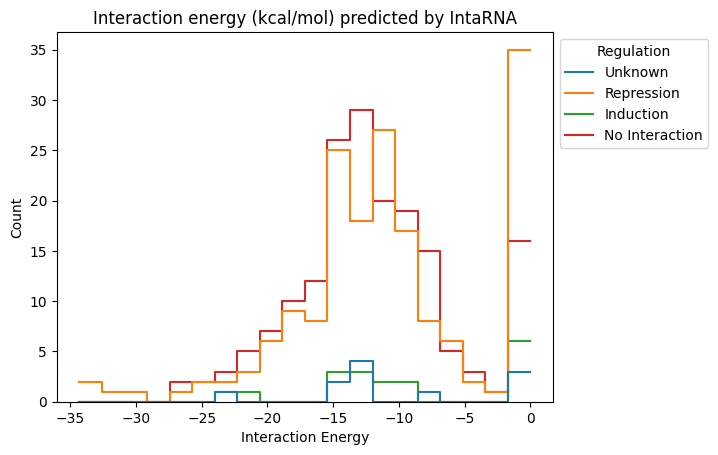

In [91]:
g = sns.histplot(data, x='Interaction Energy', hue='Regulation', element='step', bins=20, 
                 fill=False)
plt.title('Interaction energy (kcal/mol) predicted by IntaRNA')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

plt.savefig(os.path.join('data', '10_mechanisms', 'interaction_energy_histogram.png'), bbox_inches='tight', dpi=300)
plt.show()


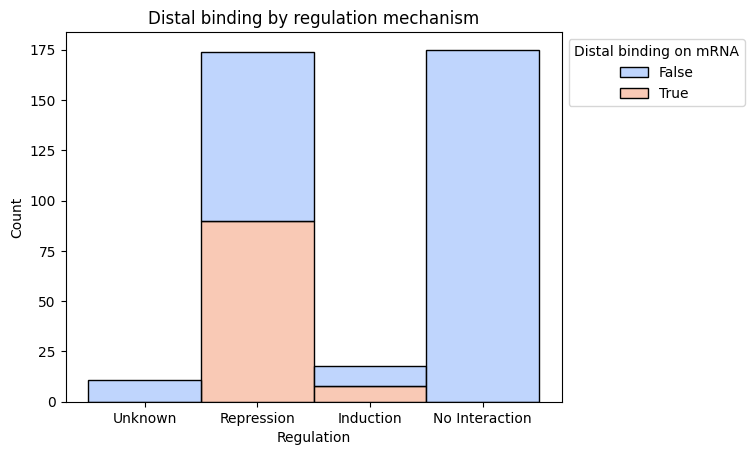

In [46]:
g = sns.histplot(data, x='Regulation', hue=data['Binding position 2'].apply(lambda x: '.' in x if type(x) == str else False), 
                 element='bars', multiple='stack', palette='coolwarm')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
g.legend_.set_title('Distal binding on mRNA')
plt.title('Distal binding by regulation mechanism')

plt.savefig(os.path.join('data', '10_mechanisms', 'distal_binding.png'), bbox_inches='tight', dpi=300)
plt.show()

# Motif differences between activation / repression

In [29]:
load_dir_st = './data/tests/2023_11_30_120342/st'

if not load_dir_st:
    config = {
        "experiment": {
            "purpose": "tests",
            "no_visualisations": False,
            "no_numerical": False,
            "debug_mode": False
        }
    }
    data_writer = None
    config, data_writer = script_preamble(config, data_writer)
    
    run_bpRNA(interaction_data, merged, data_writer)
    
    load_dir_st = os.path.join(data_writer.write_dir, 'st')


In [30]:
motifs = aggregate_motifs(sim_data=interaction_data, dir_st=load_dir_st)


In [31]:
motifs['Regulation'] = ''
# motifs[('Num in seq', 'Regulation')] = ''

for i, r in data.iterrows():
    i1 = r['Interactor 1']
    i2 = r['Interactor 2']
    motifs.loc[(motifs['sRNA'] == i1) & (motifs['Target'] == i2), 'Regulation'] = r['Regulation']
    # data.loc[i, 'Num in seq'] = motifs[(motifs['sRNA'] == i1) & (motifs['Target'] == i2)]['Num in seq']
    # data.loc[i, 'Mean Length'] = motifs[(motifs['sRNA'] == i1) & (motifs['Target'] == i2)]['Mean Length']

KeyError: 'sRNA'

KeyError: 'Num in seq'

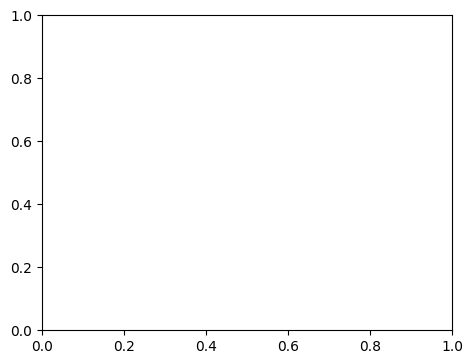

In [ ]:
inductions = ['Induction', 'Repression', 'No Interaction']

fig = plt.figure(figsize=(18, 9))
fig.subplots_adjust(wspace=0.2, hspace=0.2)
for i, n in enumerate(inductions):
    ax = plt.subplot(2,len(inductions),i+1)
    sns.barplot(motifs[motifs['Regulation'] == n]['Num in seq'])
    # sns.histplot(motifs[motifs['Regulation'] == n]['Num in seq'], x=motifs['Num in seq'].columns[2], hue='Regulation')
    plt.title(n)
    if i == 0:
        plt.ylabel('Count per interaction')

for i, n in enumerate(inductions):
    ax = plt.subplot(2,len(inductions),i+1+len(inductions))
    sns.barplot(motifs[motifs['Regulation'] == n]['Mean Length'])
    if i == 0:
        plt.ylabel('Mean length of motif')

plt.suptitle('Regulations across motifs')
# plt.savefig(os.path.join('data', '10_mechanisms', 'motifs_regulations.png'), bbox_inches='tight', dpi=300)


# Sequence differences

In [58]:
data['bpList_first'] = get_nth_elements(data['bpList'].apply(lambda bb: string_to_tuple_list(bb)), empty_replacement=[], n=0)
data['bpList_second'] = get_nth_elements(data['bpList'].apply(lambda bb: string_to_tuple_list(bb)), empty_replacement=[], n=1)

In [61]:
data['Sequence 2 bpseqs'] = list(map(lambda x: x[0][x[1][0]:x[1][-1]] if x[1] else '', zip(data['Sequence 2'].to_list(), data['bpList_first'].to_list())))
data['Sequence 1 bpseqs'] = list(map(lambda x: x[0][x[1][-1]:x[1][0]] if x[1] else '', zip(data['Sequence 1'].to_list(), data['bpList_second'].to_list())))

### GC Content

In [63]:
data['GC content 2'] = data['Sequence 2 bpseqs'].apply(lambda x: sum([1 for xx in x if xx == 'C' or (xx == 'G')]) / len(x) if x else 0)
data['GC content 1'] = data['Sequence 1 bpseqs'].apply(lambda x: sum([1 for xx in x if xx == 'C' or (xx == 'G')]) / len(x) if x else 0)
data['AU content 2'] = data['Sequence 2 bpseqs'].apply(lambda x: sum([1 for xx in x if xx == 'A' or (xx == 'U')]) / len(x) if x else 0)
data['AU content 1'] = data['Sequence 1 bpseqs'].apply(lambda x: sum([1 for xx in x if xx == 'A' or (xx == 'U')]) / len(x) if x else 0)

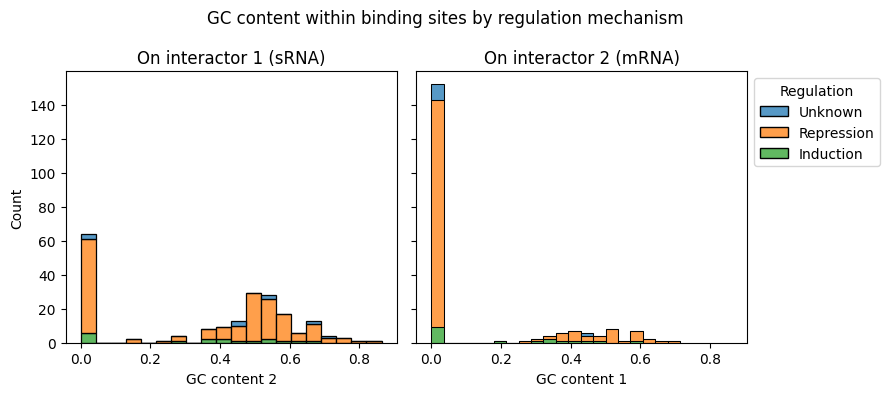

In [88]:

fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.5)

ax = axs[0]
g = sns.histplot(data[data['Regulation'] != 'No Interaction'], 
                x='GC content 2', hue='Regulation', 
                 element='bars', multiple='stack', bins=20, fill=True, legend=False, ax=ax)
ax.set_title('On interactor 1 (sRNA)')

ax = axs[1]
g = sns.histplot(data[data['Regulation'] != 'No Interaction'], 
                x='GC content 1', hue='Regulation', 
                 element='bars', multiple='stack', bins=20, fill=True, ax=ax)
ax.set_title('On interactor 2 (mRNA)')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

plt.suptitle('GC content within binding sites by regulation mechanism')
plt.tight_layout()
plt.savefig(os.path.join('data', '10_mechanisms', 'gc_content.png'), bbox_inches='tight', dpi=300)
plt.show()

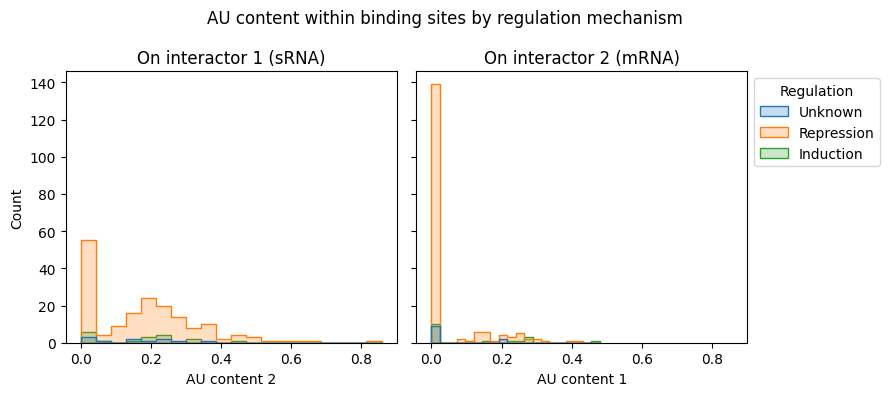

In [83]:

fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.5)

ax = axs[0]
g = sns.histplot(data[data['Regulation'] != 'No Interaction'], x='AU content 2', hue='Regulation', element='step', bins=20, 
                 fill=True, legend=False, ax=ax)
ax.set_title('On interactor 1 (sRNA)')

ax = axs[1]
g = sns.histplot(data[data['Regulation'] != 'No Interaction'], x='AU content 1', hue='Regulation', element='step', bins=20, 
                 fill=True, legend=True, ax=ax)
ax.set_title('On interactor 2 (mRNA)')
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))

plt.suptitle('AU content within binding sites by regulation mechanism')
plt.tight_layout()
plt.savefig(os.path.join('data', '10_mechanisms', 'au_content.png'), bbox_inches='tight', dpi=300)
plt.show()


# Binding site differences

# Protein involvements